<a href="https://colab.research.google.com/github/FaraahJ/Data-Science-Internship-Assignments/blob/main/Wk8_RNN_LSTM(full).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from datetime import date

In [86]:
clim = pd.read_csv('/content/climate_2009_2016.csv', index_col = 0)

In [87]:
clim = clim.reset_index()
clim.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [88]:
df = clim[['Date Time','T (degC)']].rename(columns = {'T (degC)':'T','Date Time':'datetime'})
df.head()

,datetime,T
0,01.01.2009 00:10:00,-8.02
1,01.01.2009 00:20:00,-8.41
2,01.01.2009 00:30:00,-8.51
3,01.01.2009 00:40:00,-8.31
4,01.01.2009 00:50:00,-8.27


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   datetime  420551 non-null  object 
 1   T         420551 non-null  float64
dtypes: float64(1), object(1)
memory usage: 6.4+ MB


In [90]:
import datetime
df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')

# error for data in position 102248, changed format to 'mixed'

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  420551 non-null  datetime64[ns]
 1   T         420551 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 6.4 MB


In [92]:
df.head()
# showing temperature recorded every 10 mins

,datetime,T
0,2009-01-01 00:10:00,-8.02
1,2009-01-01 00:20:00,-8.41
2,2009-01-01 00:30:00,-8.51
3,2009-01-01 00:40:00,-8.31
4,2009-01-01 00:50:00,-8.27


In [93]:
# hourly records are required - taking every 6th record of dataset via merging every 5 rows
df_hour_lvl = df[5::6].reset_index().drop('index', axis=1)

df_hour_lvl.head()
#now displaying hourly data

,datetime,T
0,2009-01-01 01:00:00,-8.05
1,2009-01-01 02:00:00,-8.88
2,2009-01-01 03:00:00,-8.81
3,2009-01-01 04:00:00,-9.05
4,2009-01-01 05:00:00,-9.63


/tmp/ipykernel_3878/345882731.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_hour_lvl['T'])


<Axes: xlabel='T', ylabel='Density'>

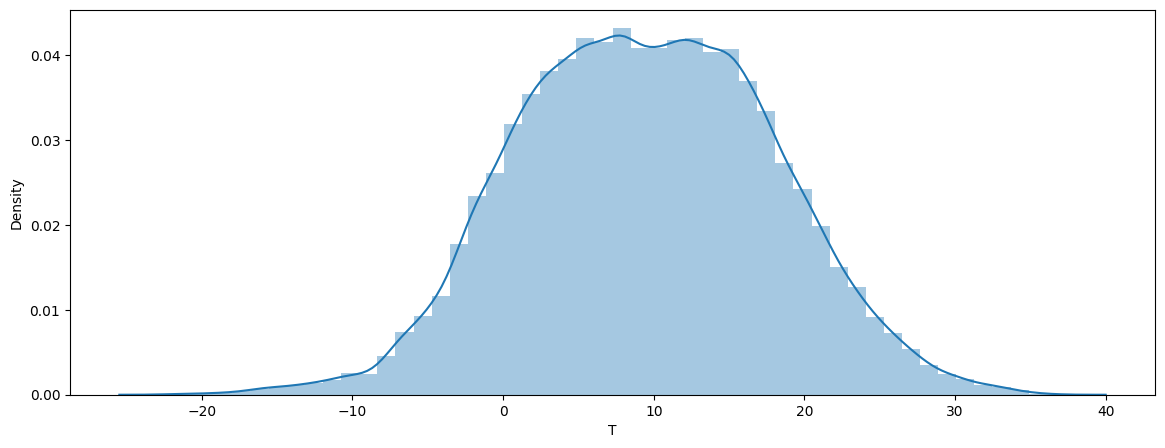

In [94]:
# viewing data distribution
plt.figure(figsize = (14,5))
sns.distplot(df_hour_lvl['T'])

In [95]:
df_hour_lvl['T'] = (df_hour_lvl['T'].mean()) / df_hour_lvl['T'].std()

In [96]:
# the input X sequence must be a 2D array [no. of sample records, no. of sample inputs], while the input y sequence must be a 1D array

# creating function including dataset (df) and sample inputs (input_sequence)
def Sequential_Input_LSTM(df, input_sequence):
    df_np = df.to_numpy()
    X = [] #create two empty lists
    y = []

    for i in range(len(df_np) - input_sequence):
        row = [a for a in df_np[i:i + input_sequence]] #adding 'n' no. of samples to training dataset
        X.append(row)
        label = df_np[i + input_sequence] #adding corresponding target feature variables of dataset in y list
        y.append(label)

    return np.array(X), np.array(y)

In [97]:
n_input = 100 #increasing no. of sample inputs

df_min_model_data = df_hour_lvl['T']

X, y = Sequential_Input_LSTM(df_min_model_data, n_input)

In [98]:
X.shape, y.shape
#16941 sequence samples with 100 inputs at given time for x

((69991, 100), (69991,))

In [99]:
# Training data - 1400 rows for training
X_train, y_train = X[:1400], y[:1400]

# Validation data - 200 rows for validation
X_val, y_val = X[1400:1600], y[1400:1600]

# Test data
X_test, y_test = X[1600:], y[1600:]

In [100]:
X_train.shape, y_train.shape

((1400, 100), (1400,))

In [101]:
X_val.shape, y_val.shape

((200, 100), (200,))

In [102]:
X_test.shape, y_test.shape

((68391, 100), (68391,))

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# stratify removed- ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [104]:
## days

print('Temp :')
print()
print(f'Total days      : {len(df_hour_lvl)/24}')
print(f'Training days   : {len(X_train)/24}')
print(f'Validation days : {len(X_val)/24}')
print(f'Testing days    : {len(X_test)/24}')

Temp :

Total days      : 2920.4583333333335
Training days   : 2333.0
Validation days : 8.333333333333334
Testing days    : 583.2916666666666


In [105]:
# Building tensorflow LSTM model
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import * #LSTM and dense layers
from tensorflow.keras.callbacks import EarlyStopping #monitors and stops loss if no significant change
from tensorflow.keras.metrics import RootMeanSquaredError, MeanSquaredError
from tensorflow.keras.optimizers import Adam #training algorithm

In [106]:
n_features = 1      # number of input variables used for forecast (here, only 1: temperature)

model1 = Sequential()

model1.add(InputLayer((n_input,n_features)))
model1.add(LSTM(100, return_sequences = True))
model1.add(LSTM(100, return_sequences = True))
model1.add(LSTM(50))
model1.add(Dense(8, activation = 'relu')) # fully connected layers
model1.add(Dense(1, activation = 'linear')) # linear activation function for regression/forecasting

model1.summary()
Model: "sequential_1"

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 100, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,817 (593.04 KB)

 Trainable params: 151,817 (593.04 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2) # if there's no change in loss for 2 epochs, model will stop learning

model1.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate = 0.0001), metrics = [RootMeanSquaredError()])

In [108]:
model1.fit(X_train, y_train, validation_data = (X_val, y_val), epochs = 50, callbacks = [early_stop])

# ValueError: No gradients provided for any variable.

Epoch 1/50


ValueError: No gradients provided for any variable.